In [24]:
from sklearn.datasets import make_classification
import numpy as np

In [25]:
X,y = make_classification(n_samples=100,n_features=2,n_classes=2,n_informative=1,n_redundant=0,n_clusters_per_class=1,random_state=42,hypercube=False)

In [26]:
import matplotlib.pyplot as plt

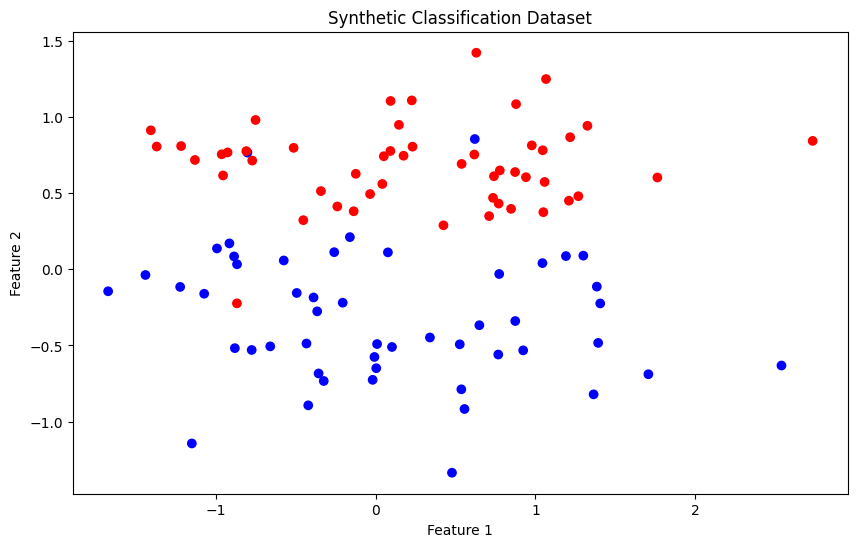

In [27]:
plt.figure(figsize=(10,6))
plt.scatter(X[:,0],X[:,1],c=y,cmap='bwr')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.title('Synthetic Classification Dataset')
plt.show()

In [28]:
def step(z):
    return 1 if z >= 0 else 0

def perceptron(X,y):
    X = np.insert(X,0,1,axis=1) # Add bias term
    weights = np.zeros(X.shape[1])
    lr = 0.1 # Learning rate
    for _ in range(1000): # Max iterations
        for i in range(len(X)):
            j = np.random.randint(0, len(X)-1) # Randomly select 
            y_hat = step(np.dot(X[j], weights)) # Prediction
            weights = weights + lr * (y[j] - y_hat) * X[j] # Update weights
    
    return weights[0], weights[1:]

In [29]:
np.dot(np.insert(X[0], 0, 1), [1,1,1])

0.748488603646543

In [30]:
y[0]

0

In [31]:
intercept,coeff = perceptron(X,y)
print(f'Intercept: {intercept}, Coefficients: {coeff}')

Intercept: -0.10000000000000003, Coefficients: [0.08875845 0.36254195]


In [32]:
m = -coeff[0]/coeff[1]
b = -intercept/coeff[1]

x_input = np.linspace(-3,3,100)
y_input = m * x_input + b

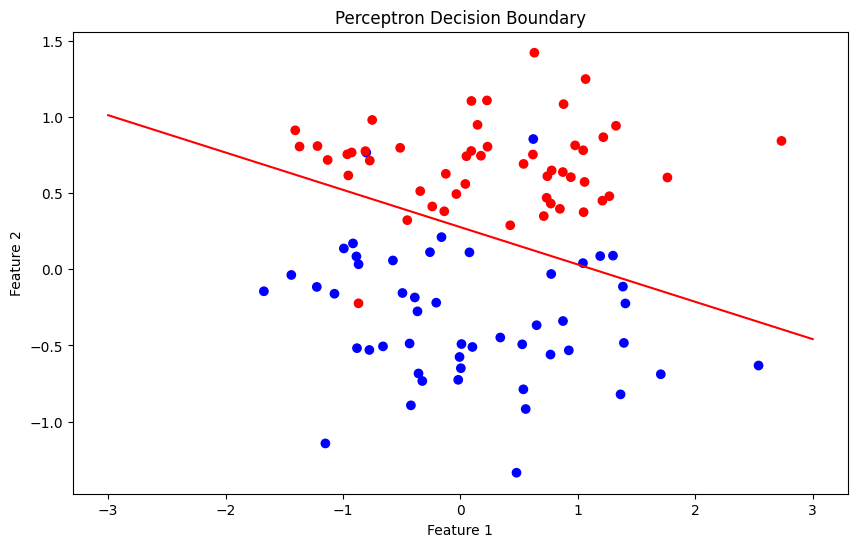

In [33]:
plt.figure(figsize=(10,6))
plt.plot(x_input, y_input, 'r-')
plt.scatter(X[:,0],X[:,1],c=y,cmap='bwr')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.title('Perceptron Decision Boundary')
plt.show()

Logistic Regression Accuracy: 0.97


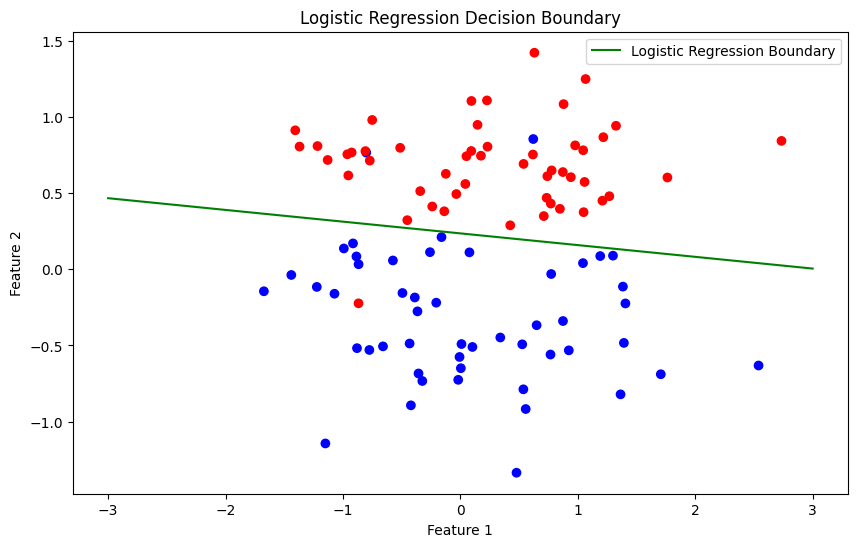

In [36]:
from pyexpat import model

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

model = LogisticRegression()
model.fit(X,y)
y_pred = model.predict(X)
accuracy = accuracy_score(y, y_pred)
print(f'Logistic Regression Accuracy: {accuracy:.2f}')

m = -model.coef_[0][0]/model.coef_[0][1]
b = -model.intercept_[0]/model.coef_[0][1]

x_input = np.linspace(-3,3,100)
y_input = m * x_input + b   
plt.figure(figsize=(10,6))
plt.plot(x_input, y_input, 'g-', label='Logistic Regression Boundary')
plt.scatter(X[:,0],X[:,1],c=y,cmap='bwr')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.title('Logistic Regression Decision Boundary')
plt.legend()
plt.show()